In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Desafio Prático IV - Página1.csv", decimal=',')
df

,Municipio,Populacao,IDH,Gini,TaxaDesemprego,PIB_per_capita,TaxaFecundidade
0,Maceió,1.029.129,0.705,0.61,16.1,"R$ 21.000,00",2.22
1,Macapá,512.902,0.720,0.60,13.7,"R$ 22.000,00",2.48
2,Manaus,2.323.789,0.720,0.60,15.4,"R$ 25.000,00",2.59
3,São Luís,1.108.975,0.730,0.60,14.5,"R$ 22.000,00",2.56
4,Rio Branco,419.452,0.725,0.59,14.2,"R$ 21.000,00",2.95
5,Recife,1.653.461,0.735,0.59,13.9,"R$ 24.000,00",1.92
6,Porto Velho,539.354,0.735,0.58,13.0,"R$ 24.000,00",2.16
7,Belém,1.496.889,0.745,0.58,14.8,"R$ 23.000,00",2.50
8,Salvador,2.900.319,0.759,0.58,14.0,"R$ 27.000,00",2.05
9,Fortaleza,2.686.612,0.754,0.57,13.2,"R$ 26.000,00",1.99


In [3]:
# Tratando os dados

print(f'Quantidade de linhas: {df.shape}\n')

print('Antes:')
print(df.dtypes)

df['Populacao'] = df['Populacao'].astype(str).str.replace('.', '').astype('int64')

df["PIB_per_capita"] = (
    df["PIB_per_capita"].astype(str).str.replace("R$", "", regex=False)
    .str.replace(".", "",regex=False)   
    .str.replace(",", ".",regex=False).astype('float64')
)

print('\n')
print('Depois: ')
print(df.dtypes)
df


Quantidade de linhas: (27, 7)

Antes:
Municipio           object
Populacao           object
IDH                float64
Gini               float64
TaxaDesemprego     float64
PIB_per_capita      object
TaxaFecundidade    float64
dtype: object


Depois: 
Municipio           object
Populacao            int64
IDH                float64
Gini               float64
TaxaDesemprego     float64
PIB_per_capita     float64
TaxaFecundidade    float64
dtype: object


,Municipio,Populacao,IDH,Gini,TaxaDesemprego,PIB_per_capita,TaxaFecundidade
0,Maceió,1029129,0.705,0.61,16.1,21000.0,2.22
1,Macapá,512902,0.720,0.60,13.7,22000.0,2.48
2,Manaus,2323789,0.720,0.60,15.4,25000.0,2.59
3,São Luís,1108975,0.730,0.60,14.5,22000.0,2.56
4,Rio Branco,419452,0.725,0.59,14.2,21000.0,2.95
5,Recife,1653461,0.735,0.59,13.9,24000.0,1.92
6,Porto Velho,539354,0.735,0.58,13.0,24000.0,2.16
7,Belém,1496889,0.745,0.58,14.8,23000.0,2.50
8,Salvador,2900319,0.759,0.58,14.0,27000.0,2.05
9,Fortaleza,2686612,0.754,0.57,13.2,26000.0,1.99


In [4]:
idh_abaixo_75 = df[df['IDH'] < 0.75]
idh_abaixo_75

,Municipio,Populacao,IDH,Gini,TaxaDesemprego,PIB_per_capita,TaxaFecundidade
0,Maceió,1029129,0.705,0.61,16.1,21000.0,2.22
1,Macapá,512902,0.720,0.60,13.7,22000.0,2.48
2,Manaus,2323789,0.720,0.60,15.4,25000.0,2.59
3,São Luís,1108975,0.730,0.60,14.5,22000.0,2.56
4,Rio Branco,419452,0.725,0.59,14.2,21000.0,2.95
5,Recife,1653461,0.735,0.59,13.9,24000.0,1.92
6,Porto Velho,539354,0.735,0.58,13.0,24000.0,2.16
7,Belém,1496889,0.745,0.58,14.8,23000.0,2.50
10,Teresina,868075,0.740,0.56,11.3,23000.0,1.99


In [5]:
media_pib = idh_abaixo_75['PIB_per_capita'].mean()
print(media_pib)

22777.777777777777


In [6]:
idh_acima_75 = df[df['IDH'] >= 0.75]
media_pib2 = idh_acima_75['PIB_per_capita'].mean()
print(media_pib2)

idh_acima_75


35777.77777777778


,Municipio,Populacao,IDH,Gini,TaxaDesemprego,PIB_per_capita,TaxaFecundidade
8,Salvador,2900319,0.759,0.58,14.0,27000.0,2.05
9,Fortaleza,2686612,0.754,0.57,13.2,26000.0,1.99
11,Boa Vista,436591,0.750,0.56,10.9,28000.0,2.41
12,Aracaju,664908,0.760,0.55,12.5,27000.0,1.95
13,Natal,890480,0.770,0.55,12.1,26000.0,1.98
14,Palmas,306296,0.770,0.54,9.8,27000.0,2.41
15,Rio de Janeiro,6775561,0.799,0.54,12.3,40000.0,1.68
16,João Pessoa,817511,0.780,0.53,11.7,25000.0,1.95
17,São Paulo,12396372,0.805,0.53,10.2,48000.0,1.66
18,Cuiabá,618124,0.785,0.50,9.6,29000.0,2.04


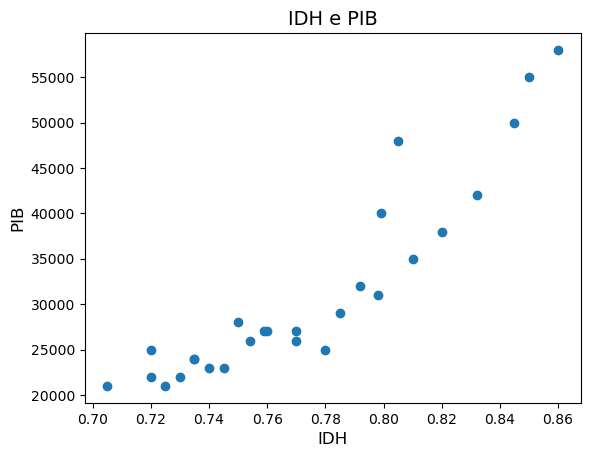

In [7]:
idh = df['IDH']
pib = df['PIB_per_capita']
gini = df['Gini']
desemprego = df['TaxaDesemprego']
fecundidade = df['TaxaFecundidade']

plt.title("IDH e PIB", fontsize=14)
plt.xlabel("IDH", fontsize=12)
plt.ylabel("PIB", fontsize=12)
plt.scatter(idh,pib)
plt.show()


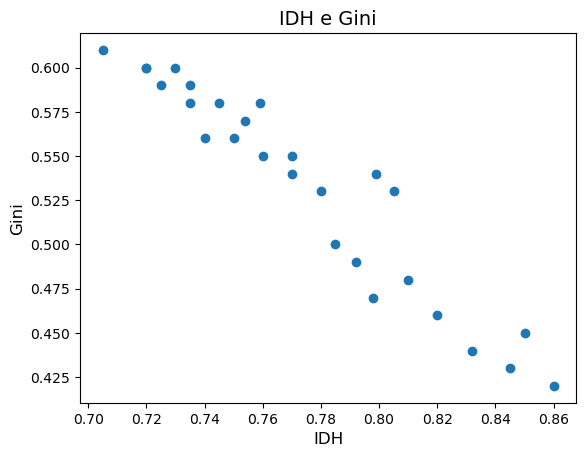

In [8]:
plt.title("IDH e Gini", fontsize=14)
plt.xlabel("IDH", fontsize=12)
plt.ylabel("Gini", fontsize=12)
plt.scatter(idh,gini)
plt.show()


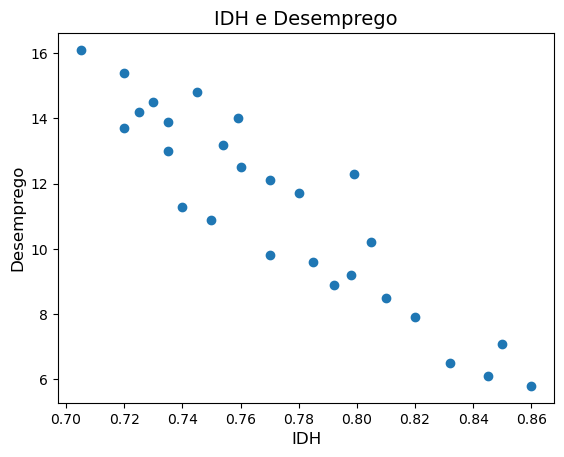

In [9]:
plt.title("IDH e Desemprego", fontsize=14)
plt.xlabel("IDH", fontsize=12)
plt.ylabel("Desemprego", fontsize=12)
plt.scatter(idh,desemprego)
plt.show()

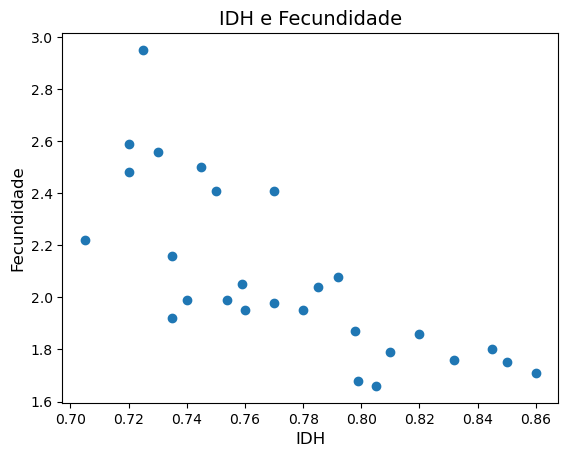

In [10]:
plt.title("IDH e Fecundidade", fontsize=14)
plt.xlabel("IDH", fontsize=12)
plt.ylabel("Fecundidade", fontsize=12)
plt.scatter(idh,fecundidade)
plt.show()

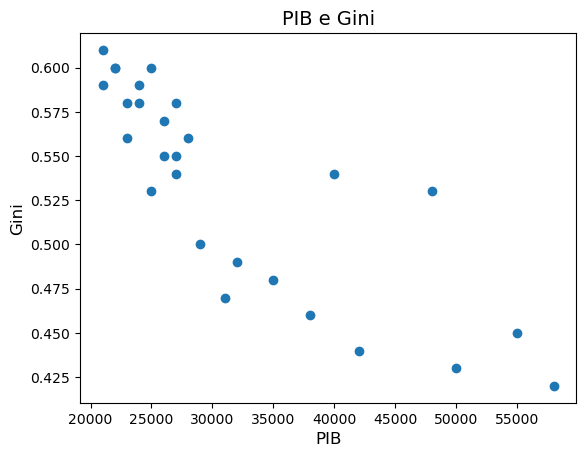

In [11]:
plt.title("PIB e Gini", fontsize=14)
plt.xlabel("PIB", fontsize=12)
plt.ylabel("Gini", fontsize=12)
plt.scatter(pib,gini)
plt.show()


In [12]:
correlacao1 = df['PIB_per_capita'].corr(df['IDH'])
correlacao2 = df['PIB_per_capita'].corr(df['Gini'])
correlacao3 = df['IDH'].corr(df['Gini'])

print(correlacao1)
print(correlacao2)
correlacao3 = df['IDH'].corr(df['Gini'])
print(correlacao3)

0.914722837448124
-0.8292374620000392
-0.9579830965771535


In [13]:
taxa_desemprego1 = idh_acima_75['TaxaDesemprego'].mean()
taxa_desemprego2 = idh_abaixo_75['TaxaDesemprego'].mean()

print(taxa_desemprego1)
print(taxa_desemprego2)

print(taxa_desemprego2 - taxa_desemprego1)

9.794444444444444
14.100000000000001
4.305555555555557


In [14]:
mun_mais_desiguais = df.nlargest(3,'Gini')
mun_mais_desiguais

,Municipio,Populacao,IDH,Gini,TaxaDesemprego,PIB_per_capita,TaxaFecundidade
0,Maceió,1029129,0.705,0.61,16.1,21000.0,2.22
1,Macapá,512902,0.720,0.60,13.7,22000.0,2.48
2,Manaus,2323789,0.720,0.60,15.4,25000.0,2.59


In [15]:
df['score'] = (
    (df['IDH'].rank(ascending=True)) + 
    (df['PIB_per_capita'].rank(ascending=True)) + 
    (df['Gini'].rank(ascending=False)) + 
    (df['TaxaDesemprego'].rank(ascending=False))
)

piores_cidades = df.nsmallest(3, 'score')
piores_cidades


,Municipio,Populacao,IDH,Gini,TaxaDesemprego,PIB_per_capita,TaxaFecundidade,score
0,Maceió,1029129,0.705,0.61,16.1,21000.0,2.22,4.5
3,São Luís,1108975,0.730,0.60,14.5,22000.0,2.56,15.5
4,Rio Branco,419452,0.725,0.59,14.2,21000.0,2.95,16.0


In [16]:
# Proponha ao menos duas políticas públicas que possam ser aplicadas a nível federal para 
# reduzir esses problemas, levando aspectos como territorialidade, acesso a serviços essenciais e equidade na distribuição de recursos.
# Justifique sua resposta integrando os conhecimentos até aqui.


# Primeira sugestão: para redução das taxas de desemprego, aplicar programas sociais que possam auxiliar, recrutar e promover recursos para pessoas desempregadas poderia ser um ótimo passo inicial.

# Tais recursos poderiam ser cursos técnicos, ajuda financeira e networking inicial para ajudar essas pessoas a arrumarem emprego. Mas, certamente, nem todas as pessoas devem receber os mesmos auxílios financeiros e de capacitação, pois é fundamental dar prioridade para regiões demográficas onde os índices de desemprego sejam mais exacerbados e a renda local distribuída de forma tão desigual a ponto de afetar negativamente o IDH local, e consequentemente focar nas famílias com baixos recursos, acesso à educação, acesso ao transporte e maiores necessidades de renda familiar para seu sustento. Isso inclui também garantir acesso a transporte público subsidiado e a postos de atendimento (como CRAS e SINE) nessas regiões prioritárias, já que, sem esses serviços básicos, o próprio acesso ao programa fica restrito. Aplicando dessa forma esses programas de recrutamento de forma equitativa para todos.

# Segunda sugestão: em conjunto com a primeira sugestão, políticas públicas que foquem no acesso à educação para pessoas de qualquer idade, dando foco para aquelas desempregadas e que possuem uma maior desigualdade de renda familiar.

# Sendo assim, distribuindo materiais de ensino, livros, cursos de capacitação (nos moldes de programas como o Pronatec), treinamentos, estudos de finanças para aplicar ao dia a dia, e recursos financeiros para ter acesso a diversos cursos. Dessa forma, as pessoas conseguem obter maiores conhecimentos em questões de renda, educação e saúde, com um caminho mais direcionado para essas áreas, eduzindo, no médio prazo, a dependência de programas assistenciais e aumentando a empregabilidade dessas famílias.